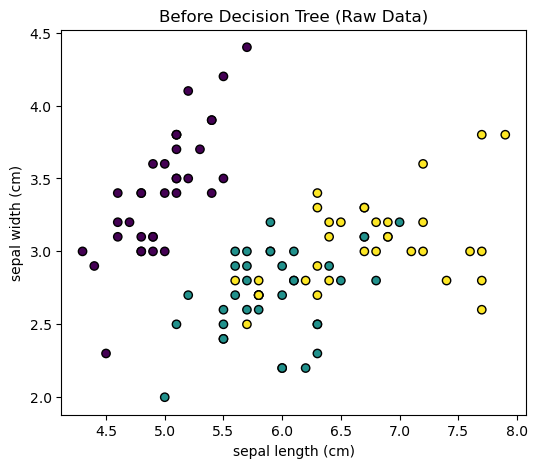

Best params: {'criterion': 'entropy', 'max_depth': 3}
Accuracy: 0.6


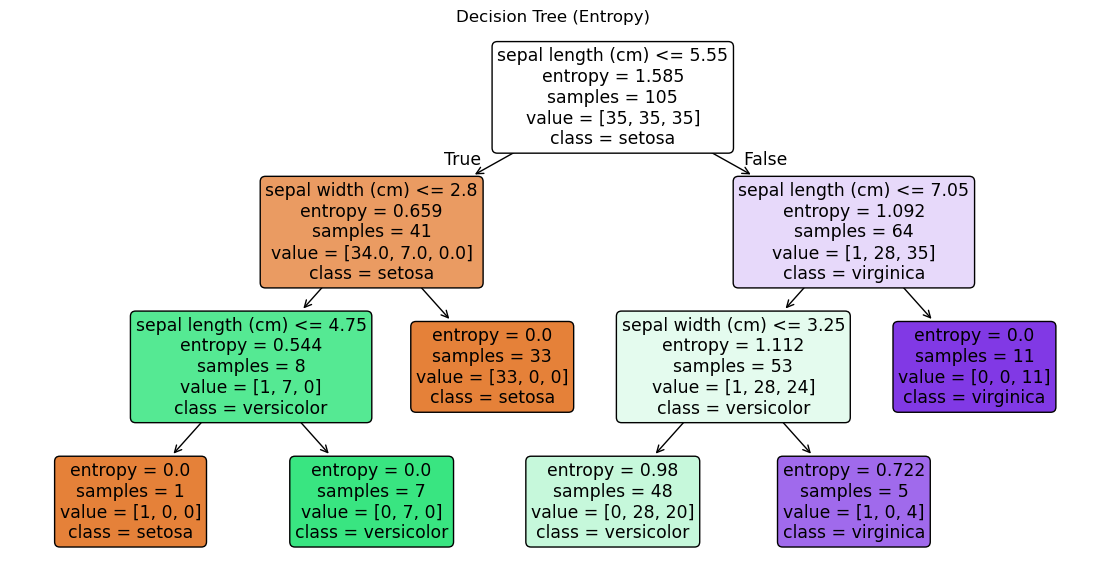

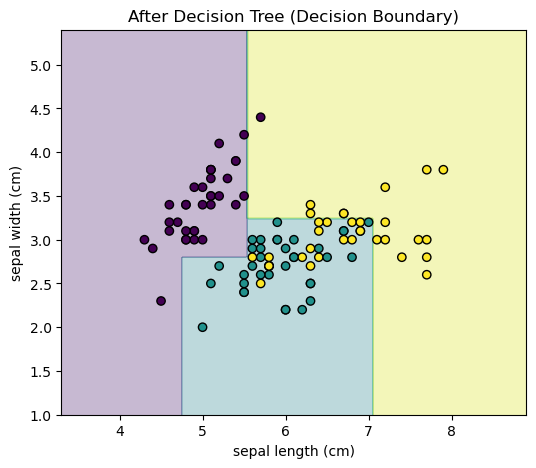

In [5]:
# =========================================
# 1. データ準備
# =========================================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data[:, :2]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# =========================================
# 2. 決定木前のプロット（重要）
# =========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Before Decision Tree (Raw Data)")
plt.show()

# =========================================
# 3. 決定木 + GridSearch
# =========================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dtc = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['entropy'],
    'max_depth': [3, 5, 7, 20]
}

gs_inst = GridSearchCV(dtc, param_grid=param_grid, cv=5)
gs_inst.fit(X_train, y_train)

# =========================================
# 4. 精度評価
# =========================================
from sklearn.metrics import accuracy_score

y_pred = gs_inst.predict(X_test)
print("Best params:", gs_inst.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

# =========================================
# 5. 決定木の可視化
# =========================================
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 7))
plot_tree(
    gs_inst.best_estimator_,
    feature_names=iris.feature_names[:2],
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree (Entropy)")
plt.show()

# =========================================
# 6. 決定境界の可視化
# =========================================
import numpy as np

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = gs_inst.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("After Decision Tree (Decision Boundary)")
plt.show()